In [102]:
import pandas as pd 
import numpy as np

In [104]:
df = pd.read_csv("C:\\Users\\marco\\Desktop\\DM2\\DM2_project\\cmi_internet.csv")

In [106]:
# BIA-BIA_Fat: percentuale di grasso corporeo, valori validi solo in [0, 100]
mask_fat_invalid = (df["BIA-BIA_Fat"] < 0) | (df["BIA-BIA_Fat"] > 100)
print(f"BIA-BIA_Fat: {mask_fat_invalid.sum()} valori irrealistici trasformati in NaN")
df.loc[mask_fat_invalid, "BIA-BIA_Fat"] = np.nan

# BIA-BIA_FMI: Fat Mass Index, non può essere negativo
mask_fmi_invalid = df["BIA-BIA_FMI"] < 0
print(f"BIA-BIA_FMI: {mask_fmi_invalid.sum()} valori irrealistici trasformati in NaN")
df.loc[mask_fmi_invalid, "BIA-BIA_FMI"] = np.nan

BIA-BIA_Fat: 169 valori irrealistici trasformati in NaN
BIA-BIA_FMI: 51 valori irrealistici trasformati in NaN


In [108]:
# Variabili con missing values (conteggio e percentuale)
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "n_missing": missing_counts,
    "pct_missing": missing_pct.round(2)
})
missing_summary = missing_summary[missing_summary["n_missing"] > 0].sort_values("pct_missing", ascending=False)

print(f"Variabili con missing values: {len(missing_summary)} su {df.shape[1]} colonne totali")
print(f"Percentuale media di missing (sulle sole variabili con NA): {missing_summary['pct_missing'].mean():.2f}%")
print()
print(missing_summary)

Variabili con missing values: 77 su 82 colonne totali
Percentuale media di missing (sulle sole variabili con NA): 35.22%

                                        n_missing  pct_missing
PCIAT-PCIAT_15                               5746        67.92
PCIAT-PCIAT_07                               5746        67.92
PCIAT-PCIAT_09                               5746        67.92
PCIAT-PCIAT_10                               5746        67.92
PCIAT-PCIAT_11                               5746        67.92
PCIAT-PCIAT_12                               5746        67.92
PCIAT-PCIAT_06                               5746        67.92
PCIAT-PCIAT_05                               5746        67.92
PCIAT-PCIAT_04                               5746        67.92
PCIAT-PCIAT_03                               5746        67.92
PCIAT-PCIAT_13                               5746        67.92
PCIAT-PCIAT_14                               5746        67.92
PCIAT-PCIAT_17                               5746        67

In [110]:
# Fill condizionato: PCIAT a 0 dove NA E sii == 0 

items_target = ["PCIAT-PCIAT_11", "PCIAT-PCIAT_17", "PCIAT-PCIAT_19"]
fill_mask = (df["sii"] == 0)
for c in items_target:
    df.loc[fill_mask & df[c].isna(), c] = 0.0

In [112]:
# Imputazione stratificata per sii (target ESCLUSO dall'imputazione, così tiene i suoi NA)
numerical_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in ["sedentary_social_withdrawal", "sii"]
]
categorical_cols = df.select_dtypes(include="object").columns

# Fallback globali, per il caso in cui un intero gruppo sii abbia NA su una colonna
global_median = df[numerical_cols].median()
global_mode = {col: df[col].mode()[0] for col in categorical_cols}

for col in numerical_cols:
    group_median = df.groupby("sii")[col].transform("median")
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(global_median[col])  # fallback se il gruppo è interamente NA

for col in categorical_cols:
    group_mode = df.groupby("sii")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df[col] = df[col].fillna(group_mode)
    df[col] = df[col].fillna(global_mode[col])  # fallback

In [114]:
# Target per l'imbalanced learning 
complete_mask = df[
    ["BIA-BIA_Activity_Level_num", "PCIAT-PCIAT_11", "PCIAT-PCIAT_17", "PCIAT-PCIAT_19"]
].notna().all(axis=1)
low_activity = df["BIA-BIA_Activity_Level_num"].isin([1, 2])
high_pciat_any = (
    df["PCIAT-PCIAT_11"].isin([4, 5]) |
    df["PCIAT-PCIAT_17"].isin([4, 5]) |
    df["PCIAT-PCIAT_19"].isin([4, 5])
)
target = pd.Series(pd.NA, index=df.index, dtype="Int64")
target.loc[complete_mask] = (low_activity & high_pciat_any).loc[complete_mask].astype("Int64")
df["sedentary_social_withdrawal"] = target



In [116]:
df = df.drop(columns=["id"])

In [118]:
# Skewness di tutte le variabili numeriche
print("SKEWNESS DELLE VARIABILI")
print("=" * 60)

skewness = df.skew(numeric_only=True).sort_values(ascending=False)

for col, sk in skewness.items():
    if sk > 1:
        nota = " --> Molto skewed a DESTRA (candidata per log)"
    elif sk < -1:
        nota = " --> Molto skewed a SINISTRA"
    elif abs(sk) < 0.5:
        nota = " --> Circa simmetrica"
    else:
        nota = " --> Moderatamente asimmetrica"
    print(f"{col}: {sk:.2f}{nota}")

SKEWNESS DELLE VARIABILI
BIA-BIA_BMC: 42.98 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_BMR: 40.13 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_DEE: 38.65 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_ICW: 36.04 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_TBW: 35.09 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_SMM: 32.42 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_ECW: 31.95 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_LST: 31.89 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_LDM: 27.32 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_FFM: 27.09 --> Molto skewed a DESTRA (candidata per log)
BIA-BIA_FFMI: 23.52 --> Molto skewed a DESTRA (candidata per log)
CGAS-CGAS_Score: 22.18 --> Molto skewed a DESTRA (candidata per log)
Fitness_Endurance-Max_Stage: 8.18 --> Molto skewed a DESTRA (candidata per log)
PCIAT-PCIAT_12: 5.39 --> Molto skewed a DESTRA (candidata per log)
sedentary_social_withdrawal: 4.75 --> Molto

In [120]:
import numpy as np

zone_cols = [col for col in df.columns if "Zone" in col]
discrete_cols = ["BIA-BIA_Activity_Level_num", "BIA-BIA_Frame_num", "Basic_Demos-Sex"]
pciat_items = [f"PCIAT-PCIAT_{str(i).zfill(2)}" for i in range(1, 21)]
exclude = ["sii", "sedentary_social_withdrawal"] + zone_cols + discrete_cols + pciat_items

log_candidates = [
    col for col, sk in skewness.items()
    if sk > 1 and col not in exclude and (df[col] >= 0).all()
]

for col in log_candidates:
    df[col] = np.log1p(df[col])

In [122]:
numeric_df = df.select_dtypes(include=['number'])



In [124]:
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 200)

corr_matrix = numeric_df.corr(method='spearman')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.70:
            high_corr.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Corr': corr_matrix.iloc[i, j]
            })
high_corr_df = pd.DataFrame(high_corr).sort_values('Corr', ascending=False)
print(f"Numero di coppie con |corr| > 0.75: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))


Numero di coppie con |corr| > 0.75: 196
             Var1              Var2     Corr
   PCIAT-PCIAT_15    PCIAT-PCIAT_17 0.918463
   PCIAT-PCIAT_13    PCIAT-PCIAT_16 0.913689
   PCIAT-PCIAT_13    PCIAT-PCIAT_15 0.911340
   PCIAT-PCIAT_05 PCIAT-PCIAT_Total 0.911271
   PCIAT-PCIAT_16    PCIAT-PCIAT_17 0.910846
   PCIAT-PCIAT_15    PCIAT-PCIAT_16 0.906651
   PCIAT-PCIAT_17    PCIAT-PCIAT_19 0.901342
   PCIAT-PCIAT_13    PCIAT-PCIAT_17 0.894234
   PCIAT-PCIAT_15 PCIAT-PCIAT_Total 0.893137
   PCIAT-PCIAT_15    PCIAT-PCIAT_20 0.892921
   PCIAT-PCIAT_09    PCIAT-PCIAT_10 0.890064
   PCIAT-PCIAT_08    PCIAT-PCIAT_17 0.889675
   PCIAT-PCIAT_08    PCIAT-PCIAT_15 0.889366
   PCIAT-PCIAT_17 PCIAT-PCIAT_Total 0.887117
   PCIAT-PCIAT_19    PCIAT-PCIAT_20 0.884757
   PCIAT-PCIAT_08    PCIAT-PCIAT_09 0.883720
   PCIAT-PCIAT_10    PCIAT-PCIAT_15 0.883618
   PCIAT-PCIAT_15    PCIAT-PCIAT_19 0.883482
   PCIAT-PCIAT_14    PCIAT-PCIAT_15 0.882839
   PCIAT-PCIAT_08    PCIAT-PCIAT_10 0.881947
   PCIAT-PCIAT_

In [126]:
# Rimozione variabili ridondanti / a rischio leakage
# ------------------------------------------------------------
# 1) Gruppo BIA: misure di composizione corporea ridondanti tra loro
#    (stesso strumento di bioimpedenziometria, stesso missing rate 21.56%).
#    Si mantengono BIA-BIA_FFM (massa magra) e BIA-BIA_BMR (metabolismo basale)
#    come rappresentanti del gruppo, per interpretabilità e diffusione in letteratura.
bia_redundant = [
    "BIA-BIA_LST", "BIA-BIA_SMM", "BIA-BIA_TBW",
    "BIA-BIA_ECW", "BIA-BIA_ICW", "BIA-BIA_FMI",
]

# 2) SDS: stessa scala in forma grezza e standardizzata (r=0.80/0.84).
#    Si mantiene la versione standardizzata SDS-SDS_Total_T.
sds_redundant = ["SDS-SDS_Total_Raw"]

# 3) Blocco PCIAT: TUTTI gli item (01-20) + PCIAT-PCIAT_Total vengono eliminati,
#    non per correlazione ma per DATA LEAKAGE: sii è derivato deterministicamente
#    da PCIAT-PCIAT_Total, quindi l'intero blocco non può comparire nella feature
#    matrix del Modulo 2. Le correlazioni altissime tra item PCIAT (fino a 0.92)
#    e tra PCIAT e sii sono struttura attesa della scala, non un problema a sé da
#    trattare item per item.
pciat_block = [f"PCIAT-PCIAT_{str(i).zfill(2)}" for i in range(1, 21)] + ["PCIAT-PCIAT_Total"]

drop_corr = bia_redundant + sds_redundant + pciat_block

print(f"Variabili rimosse: {len(drop_corr)}")
df = df.drop(columns=drop_corr)

Variabili rimosse: 28


In [128]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

In [130]:
exclude_outlier = (
    [col for col in df.columns if "Zone" in col or "Season" in col] +
    [f"PCIAT-PCIAT_{str(i).zfill(2)}" for i in range(1, 21)] +
    ["PCIAT-PCIAT_Total",  # <-- aggiunta
     "Basic_Demos-Sex", "BIA-BIA_Activity_Level_num", 
     "BIA-BIA_Frame_num", "sii", "sedentary_social_withdrawal"]
)

outlier_features = df.select_dtypes(include="number").columns.tolist()
outlier_features = [col for col in outlier_features if col not in exclude_outlier]

In [132]:
from sklearn.preprocessing import StandardScaler

X_raw = df[outlier_features].copy()  # salva una copia non scalata
X = df[outlier_features].values
scl = StandardScaler()
X = scl.fit_transform(X)

n_samples = X.shape[0]
top1_k = int(np.ceil(0.01 * n_samples))
print(f"Total samples: {n_samples}  |  Top-1% count: {top1_k}")

Total samples: 8460  |  Top-1% count: 85


In [109]:
#pip install pyod

# Module 1 – Outlier Detection

## Setup
We reuse the preprocessed dataframe from Module 0 (after imputation, log-transform, and correlated feature removal). 
We work only on continuous numerical features, excluding binary/ordinal/target columns.


## 1. Outlier Detection Methods

We apply **ten methods from different algorithmic families** to identify the top-1% outliers:

| # | Method | Family |
|---|--------|---------|
| 1 | **HBOS** – Histogram-Based Outlier Score | Naive-based |
| 2 | **Likelihood** – Gaussian Mixture | Stat-basedistba3ed |
| 4 | **EllEnv** – Elliptic Envelope | Depth-b4sed |
| 5 | **kNN** – k-Nearest Neighbors Outlier Detection | Distance-5ased |
| 6 | **LOF** – Local Outlier Factor | Density6based |
| 7 | **CBLOF** – Cluster-Based Local Outlier Factor | Clusterin7-based |
| 8 | **ABOD** – Angle-Based Outlier Detection | Ang8e-based |
| 9 | **LODA** – Lightweight On-line Detector of Anomalies | Ensem9e-based |
| 10 | **Isolation Forest** | Model-based |

Each method produces a continuous *anomaly score*; we threshold at the top 1%
to obtain binary labels (1 = outlier). Final consensus: samples flagged by
**≥5/10 methods** are considered outliers.nsidered outliers.sidered outliers.

### 1.1 HBOS (Naive-based)

In [134]:
from pyod.models.hbos import HBOS

hbos = HBOS(contamination=0.01)
hbos.fit(X)
hbos_scores  = hbos.decision_scores_       # higher = more anomalous
hbos_labels  = hbos.labels_                # 1 = outlier

print(f"HBOS  – outliers detected: {hbos_labels.sum()}  ({hbos_labels.sum()/n_samples*100:.1f}%)")


HBOS  – outliers detected: 85  (1.0%)


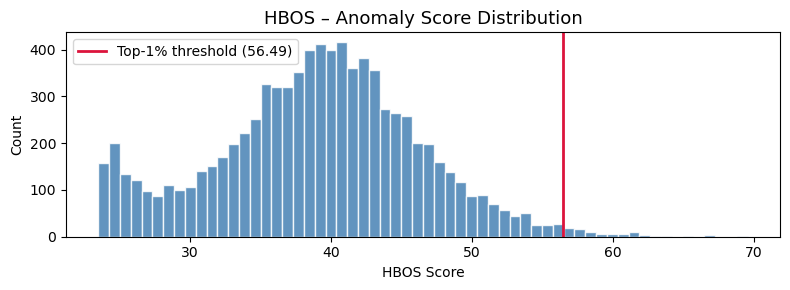

In [135]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(hbos_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
threshold_hbos = np.sort(hbos_scores)[-top1_k]
ax.axvline(threshold_hbos, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_hbos:.2f})')
ax.set_title('HBOS – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('HBOS Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()


### 1.2 Likelihood Approach (Statistical-based)

In [136]:
from pyod.models.gmm import GMM

gmm = GMM(n_components=2, contamination=0.01)
gmm.fit(X)
gmm_scores = gmm.decision_scores_
gmm_labels = gmm.labels_
print(f"GMM  – outliers detected: {gmm_labels.sum()}  ({gmm_labels.sum()/n_samples*100:.1f}%)")

GMM  – outliers detected: 85  (1.0%)


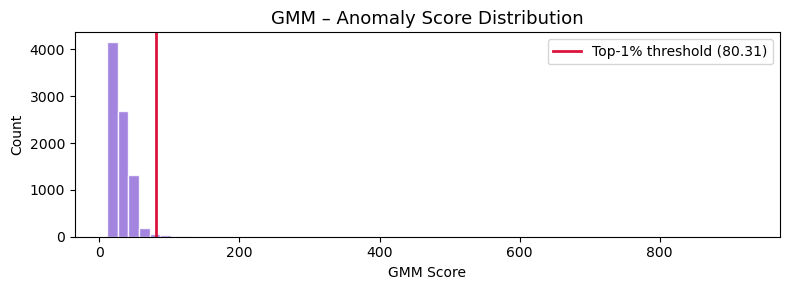

In [139]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(gmm_scores, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
threshold_gmm = np.sort(gmm_scores)[-top1_k]
ax.axvline(threshold_gmm, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_gmm:.2f})')
ax.set_title('GMM – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('GMM Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

### 1.3 EllEnv (Depth-based)

In [142]:
from sklearn.covariance import EllipticEnvelope as EE
from sklearn.preprocessing import StandardScaler

ellenv_model = EE(contamination=0.01)
ellenv_model.fit(X)
ellenv_scores = -ellenv_model.score_samples(X)    # higher = more anomalous
threshold_ellenv = np.percentile(ellenv_scores, 99)
ellenv_labels = (ellenv_scores >= threshold_ellenv).astype(int)
print(f"EllEnv – outliers detected: {ellenv_labels.sum()}  ({ellenv_labels.sum()/n_samples*100:.1f}%)")


EllEnv – outliers detected: 85  (1.0%)


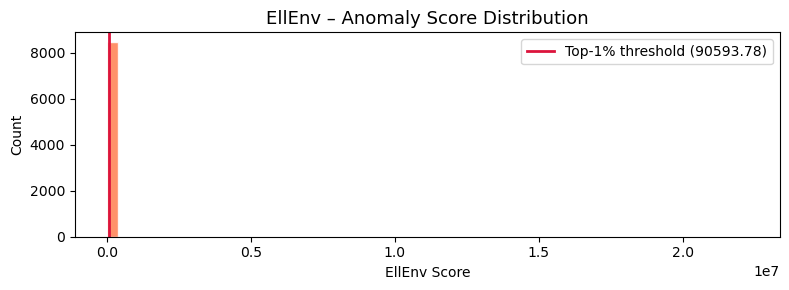

In [143]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ellenv_scores, bins=60, color='coral', edgecolor='white', alpha=0.85)
threshold_ellenv = np.sort(ellenv_scores)[-top1_k]
ax.axvline(threshold_ellenv, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_ellenv:.2f})')
ax.set_title('EllEnv – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('EllEnv Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

### 1.4 kNN (Distance

In [144]:
from pyod.models.knn import KNN

knn = KNN(n_neighbors=20, contamination=0.01)
knn.fit(X)
knn_scores  = knn.decision_scores_       # higher = more anomalous
knn_labels  = knn.labels_                # 1 = outlier

print(f"KNN  – outliers detected: {knn_labels.sum()}  ({knn_labels.sum()/n_samples*100:.1f}%)")


KNN  – outliers detected: 85  (1.0%)


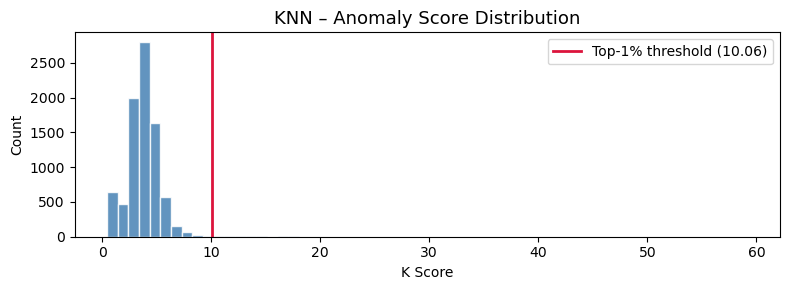

In [148]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(knn_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
threshold_knn = np.sort(knn_scores)[-top1_k]
ax.axvline(threshold_knn, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_knn:.2f})')
ax.set_title('KNN – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('K Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()


### 1.5 LOF – Local Outlier Factor (density-based)

In [150]:
from pyod.models.lof import LOF

lof = LOF(n_neighbors=20, contamination=0.01)
lof.fit(X)
lof_scores  = lof.decision_scores_       # higher = more anomalous
lof_labels  = lof.labels_                # 1 = outlier

print(f"LOF  – outliers detected: {lof_labels.sum()}  ({lof_labels.sum()/n_samples*100:.1f}%)")


LOF  – outliers detected: 85  (1.0%)


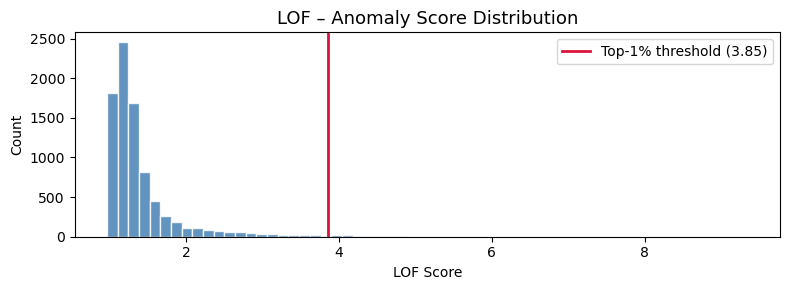

In [152]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lof_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
threshold_lof = np.sort(lof_scores)[-top1_k]
ax.axvline(threshold_lof, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_lof:.2f})')
ax.set_title('LOF – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('LOF Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

### 1.6 CBLOF (Clustering-based)

In [154]:
from pyod.models.cblof import CBLOF

cblof = CBLOF(n_clusters=8, contamination=0.01, random_state=42)
cblof.fit(X)
cblof_scores = cblof.decision_scores_
cblof_labels = cblof.labels_
print(f"CBLOF – outliers detected: {cblof_labels.sum()}  ({cblof_labels.sum()/n_samples*100:.1f}%)")

CBLOF – outliers detected: 85  (1.0%)


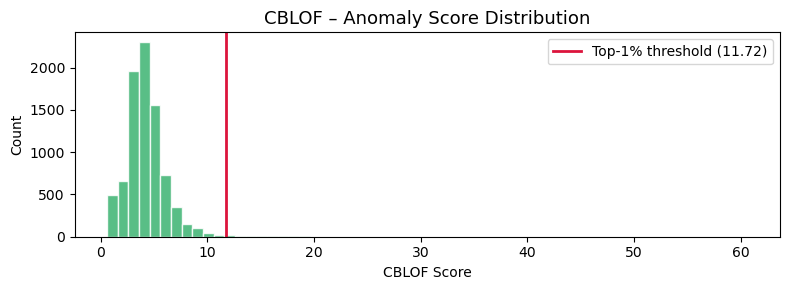

In [156]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cblof_scores, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
threshold_cblof = np.sort(cblof_scores)[-top1_k]
ax.axvline(threshold_cblof, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_cblof:.2f})')
ax.set_title('CBLOF – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('CBLOF Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

### 1.7 ABOD – Angle-Based Outlier Detection (High-Dimensional-based)

In [158]:
from pyod.models.abod import ABOD

abod = ABOD(n_neighbors=10, contamination=0.01)
abod.fit(X)
abod_scores = abod.decision_scores_
abod_labels = abod.labels_

print(f"ABOD – outliers detected: {abod_labels.sum()}  ({abod_labels.sum()/n_samples*100:.1f}%)")


ABOD – outliers detected: 85  (1.0%)


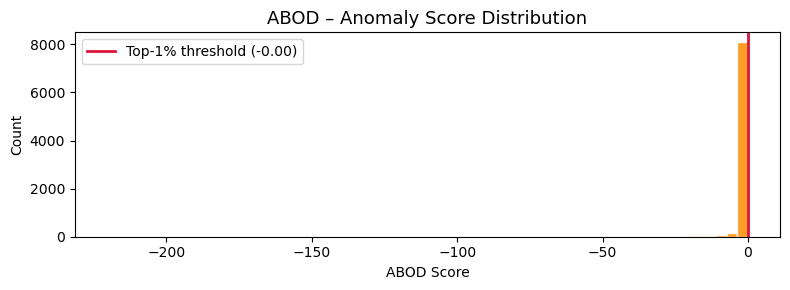

In [159]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(abod_scores, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
threshold_abod = np.sort(abod_scores)[-top1_k]
ax.axvline(threshold_abod, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_abod:.2f})')
ax.set_title('ABOD – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('ABOD Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()


### 1.8 LODA (ensemble / tree-based)

In [160]:
from pyod.models.loda import LODA

loda = LODA(contamination=0.01)
loda.fit(X)
loda_scores = loda.decision_scores_    # higher = more anomalous
loda_labels = loda.labels_             # 1 = outlier
print(f"LODA – outliers detected: {loda_labels.sum()}  ({loda_labels.sum()/n_samples*100:.1f}%)")

LODA – outliers detected: 85  (1.0%)


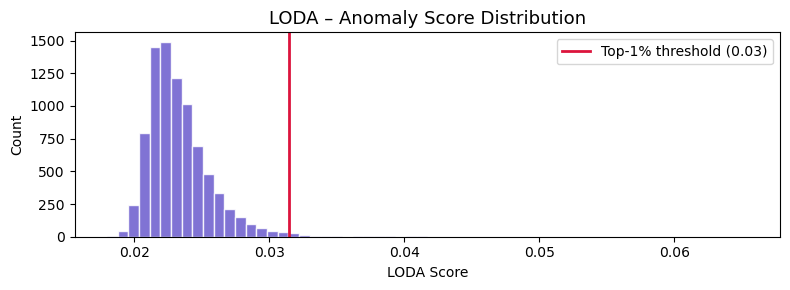

In [164]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(loda_scores, bins=60, color='slateblue', edgecolor='white', alpha=0.85)
threshold_loda = np.sort(loda_scores)[-top1_k]
ax.axvline(threshold_loda, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_loda:.2f})')
ax.set_title('LODA – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('LODA Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()


### 1.9 Isolation Forest (ensemble / tree-based)

In [166]:
from pyod.models.iforest import IForest

iforest = IForest(n_estimators=200, contamination=0.01, random_state=42)
iforest.fit(X)
if_scores = iforest.decision_scores_
if_labels = iforest.labels_

print(f"IForest – outliers detected: {if_labels.sum()}  ({if_labels.sum()/n_samples*100:.1f}%)")


IForest – outliers detected: 85  (1.0%)


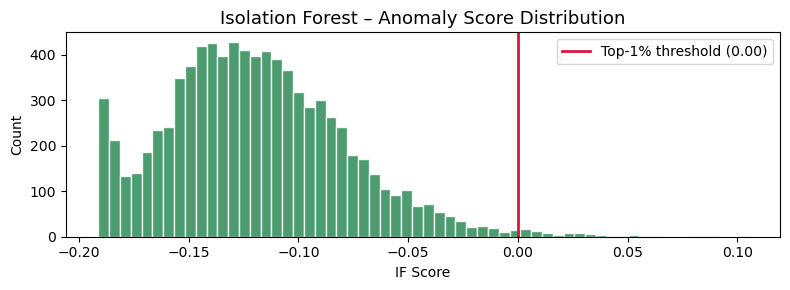

In [168]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(if_scores, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
threshold_if = np.sort(if_scores)[-top1_k]
ax.axvline(threshold_if, color='crimson', lw=2, label=f'Top-1% threshold ({threshold_if:.2f})')
ax.set_title('Isolation Forest – Anomaly Score Distribution', fontsize=13)
ax.set_xlabel('IF Score'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()


---
## 2. Comparison of the Three Methods

We compare the outlier sets using a Venn-diagram-style overlap matrix and agreement counts.


In [170]:
# Build a comparison dataframe
outlier_df = pd.DataFrame({
    'HBOS':    hbos_labels,
    'GMM':     gmm_labels,
    'EllEnv':  ellenv_labels,
    'KNN':     knn_labels,
    'LOF':     lof_labels,
    'CBLOF':   cblof_labels,
    'ABOD':    abod_labels,
    'LODA':    loda_labels,
    'IForest': if_labels
}, index=range(n_samples))

outlier_df['votes'] = outlier_df.sum(axis=1)
print("Vote distribution (0 = inlier by all, 9 = outlier by all):")
print(outlier_df['votes'].value_counts().sort_index())

Vote distribution (0 = inlier by all, 9 = outlier by all):
votes
0    8050
1     251
2      75
3      28
4      21
5      20
6      10
7       4
8       1
Name: count, dtype: int64


Jaccard similarity between outlier sets:
          HBOS    GMM  EllEnv    KNN    LOF  CBLOF   ABOD   LODA  IForest
HBOS     1.000  0.006   0.043  0.024  0.000  0.012  0.012  0.043    0.371
GMM      0.006  1.000   0.076  0.532  0.056  0.545  0.308  0.288    0.049
EllEnv   0.043  0.076   1.000  0.083  0.024  0.083  0.126  0.076    0.049
KNN      0.024  0.532   0.083  1.000  0.062  0.910  0.298  0.441    0.083
LOF      0.000  0.056   0.024  0.062  1.000  0.062  0.037  0.062    0.006
CBLOF    0.012  0.545   0.083  0.910  0.062  1.000  0.308  0.417    0.062
ABOD     0.012  0.308   0.126  0.298  0.037  0.308  1.000  0.241    0.083
LODA     0.043  0.288   0.076  0.441  0.062  0.417  0.241  1.000    0.097
IForest  0.371  0.049   0.049  0.083  0.006  0.062  0.083  0.097    1.000


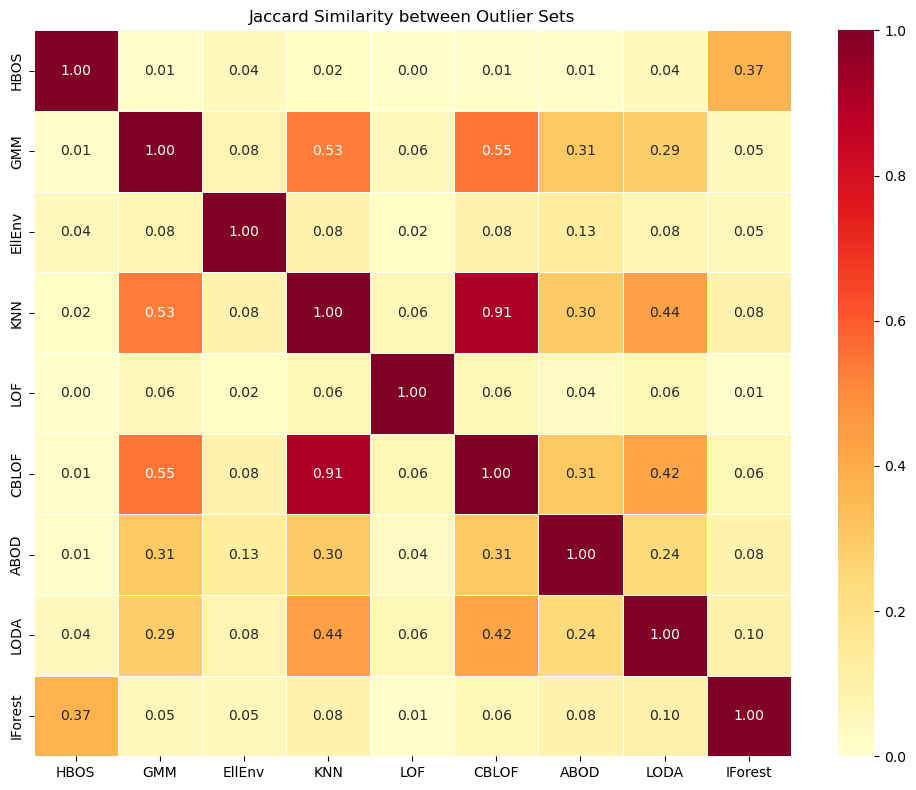

In [172]:
# Overlap matrix (Jaccard similarity between method pairs)
from itertools import combinations
methods = ['HBOS', 'GMM','EllEnv', 'KNN', 'LOF', 'CBLOF', 'ABOD', 'LODA', 'IForest']
jaccard = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m in methods:
    jaccard.loc[m, m] = 1.0
for a, b in combinations(methods, 2):
    inter = (outlier_df[a] & outlier_df[b]).sum()
    union = (outlier_df[a] | outlier_df[b]).sum()
    j = inter / union if union > 0 else 0.0
    jaccard.loc[a, b] = jaccard.loc[b, a] = round(j, 3)
print("Jaccard similarity between outlier sets:")
print(jaccard)

plt.figure(figsize=(10, 8))
sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5)
plt.title("Jaccard Similarity between Outlier Sets")
plt.tight_layout()
plt.savefig("jaccard_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

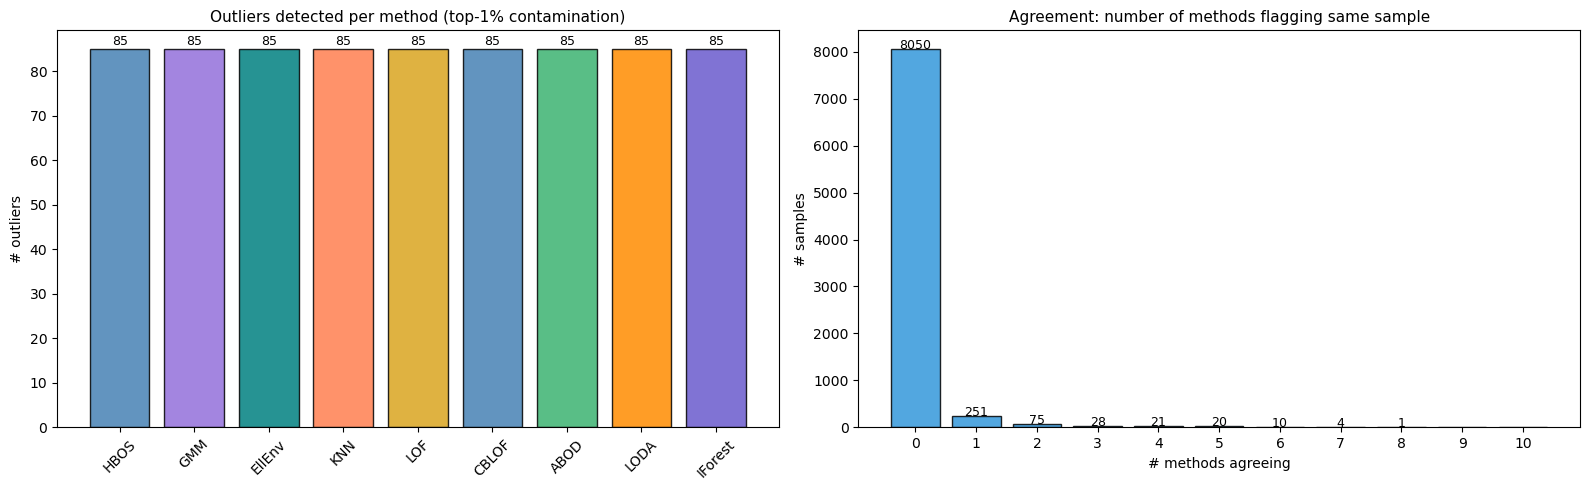

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left – counts per method
methods_list = ['HBOS', 'GMM', 'EllEnv', 'KNN', 'LOF', 'CBLOF', 'ABOD', 'LODA', 'IForest']
counts = [hbos_labels.sum(), gmm_labels.sum(), ellenv_labels.sum(),
          knn_labels.sum(), lof_labels.sum(), cblof_labels.sum(), abod_labels.sum(),
          loda_labels.sum(), if_labels.sum()]
colors = ['steelblue', 'mediumpurple', 'teal', 'coral', 'goldenrod',
          'steelblue', 'mediumseagreen', 'darkorange', 'slateblue', ]

axes[0].bar(methods_list, counts, color=colors, edgecolor='k', alpha=0.85)
axes[0].set_title('Outliers detected per method (top-1% contamination)', fontsize=11)
axes[0].set_ylabel('# outliers')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

# Right – vote distribution
vote_counts = outlier_df['votes'].value_counts().reindex(range(11), fill_value=0).sort_index()
axes[1].bar(vote_counts.index, vote_counts.values, color='#3498db', edgecolor='k', alpha=0.85)
axes[1].set_title('Agreement: number of methods flagging same sample', fontsize=11)
axes[1].set_xlabel('# methods agreeing'); axes[1].set_ylabel('# samples')
axes[1].set_xticks(range(11))
for x, y in zip(vote_counts.index, vote_counts.values):
    if y > 0:
        axes[1].text(x, y + 2, str(y), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

In [176]:
# Consensus outlier: flagged by at least 4 out of 9 methods
outlier_df['consensus'] = (outlier_df['votes'] >= 4).astype(int)
n_consensus = outlier_df['consensus'].sum()
print(f"Consensus outliers (≥4/9 methods agree): {n_consensus}  ({n_consensus/n_samples*100:.2f}%)")

Consensus outliers (≥4/9 methods agree): 56  (0.66%)


---
## 3. Visualisation with Dimensionality Reduction

We project the data onto 2D and 3D using **PCA** to visualise where outliers lie in feature space.
Consensus outliers (flagged by ≥2 methods) are highlighted in red.


### 3.1 PCA 2D

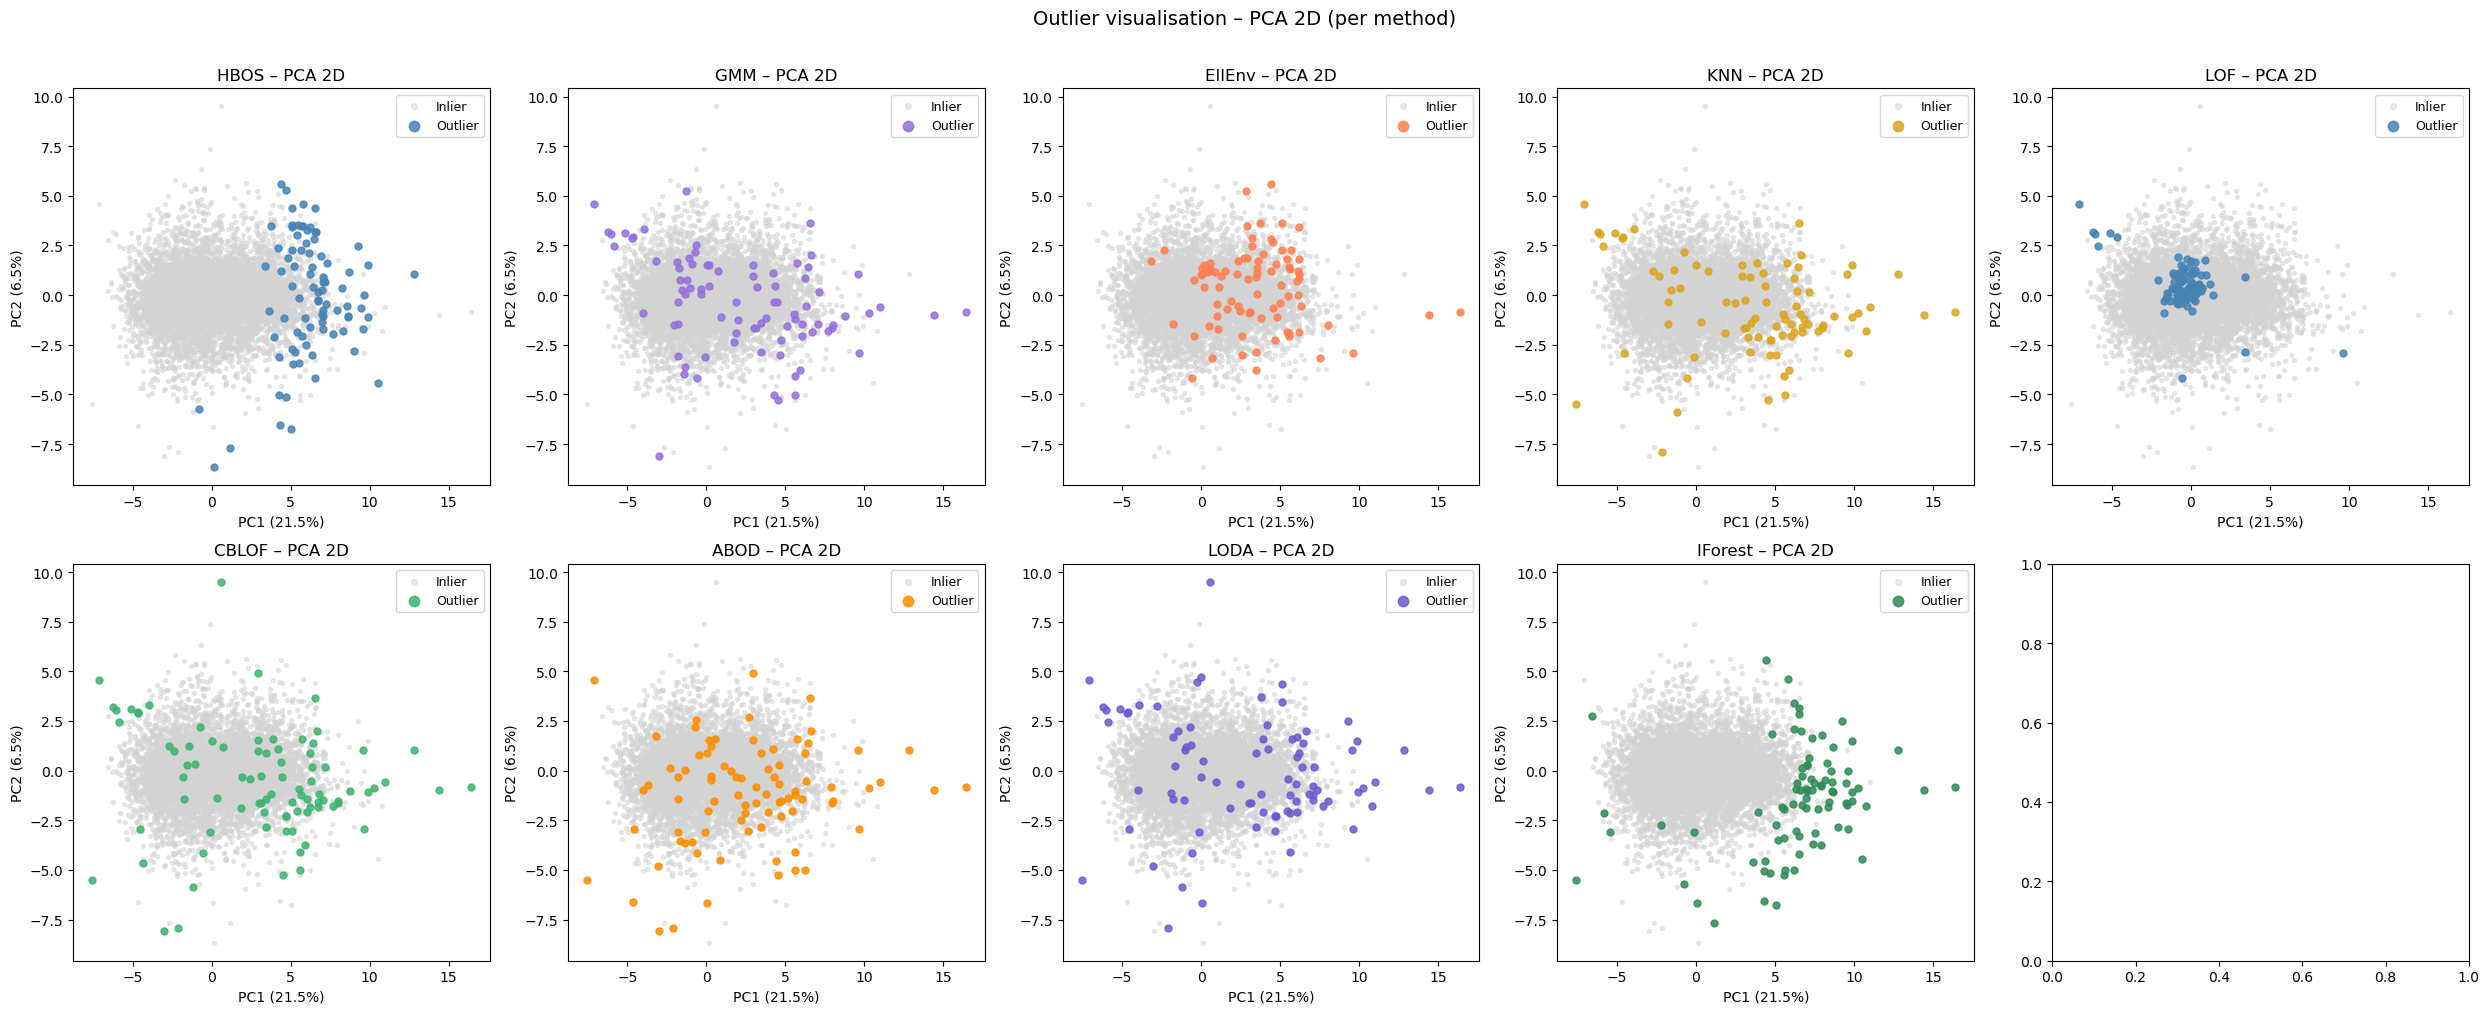

In [178]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=29)
X_2d = pca2.fit_transform(X)
consensus_mask = outlier_df['consensus'].values.astype(bool)

method_labels = [
    ('HBOS',    hbos_labels,    'steelblue'),
    ('GMM',     gmm_labels,     'mediumpurple'),
    ('EllEnv',  ellenv_labels,  'coral'),
    ('KNN',     knn_labels,     'goldenrod'),
    ('LOF',     lof_labels,     'steelblue'),
    ('CBLOF',   cblof_labels,   'mediumseagreen'),
    ('ABOD',    abod_labels,    'darkorange'),
    ('LODA',    loda_labels,    'slateblue'),
    ('IForest', if_labels,      'seagreen'),
]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for ax, (name, labels, col) in zip(axes, method_labels):
    inlier = labels == 0
    out_m  = labels == 1
    ax.scatter(X_2d[inlier, 0], X_2d[inlier, 1], c='lightgrey', s=8,  alpha=0.5, label='Inlier')
    ax.scatter(X_2d[out_m,  0], X_2d[out_m,  1], c=col,         s=25, alpha=0.85, label='Outlier', zorder=3)
    ax.set_title(f'{name} – PCA 2D', fontsize=12)
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=1.5, fontsize=9)

plt.suptitle('Outlier visualisation – PCA 2D (per method)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
axes[-1].set_visible(False)  # nascondi il decimo subplot vuoto

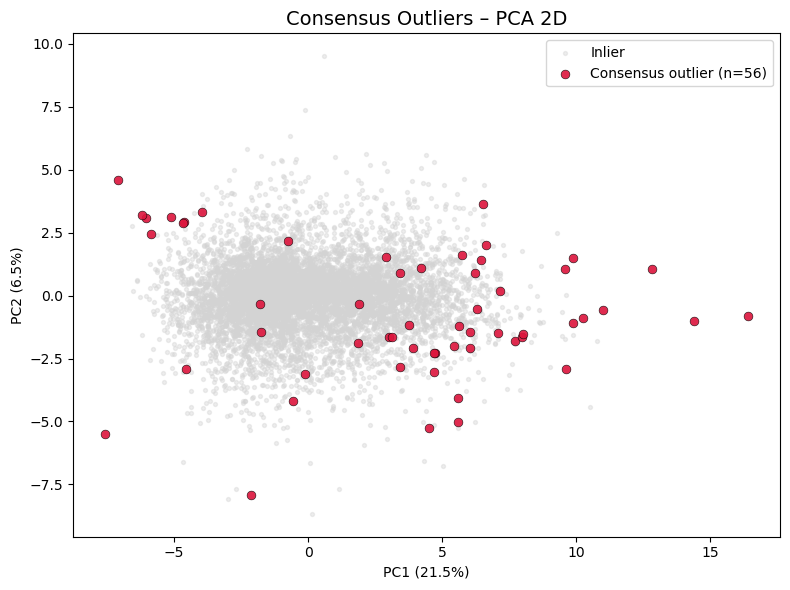

In [180]:
# Consensus plot 2D
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_2d[~consensus_mask, 0], X_2d[~consensus_mask, 1],
           c='lightgrey', s=8, alpha=0.4, label='Inlier')
ax.scatter(X_2d[consensus_mask,  0], X_2d[consensus_mask,  1],
           c='crimson', s=40, alpha=0.9, edgecolors='k', linewidths=0.4,
           label=f'Consensus outlier (n={n_consensus})', zorder=4)
ax.set_title('Consensus Outliers – PCA 2D', fontsize=14)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("consensus_outliers_pca2d.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.2 PCA 3D

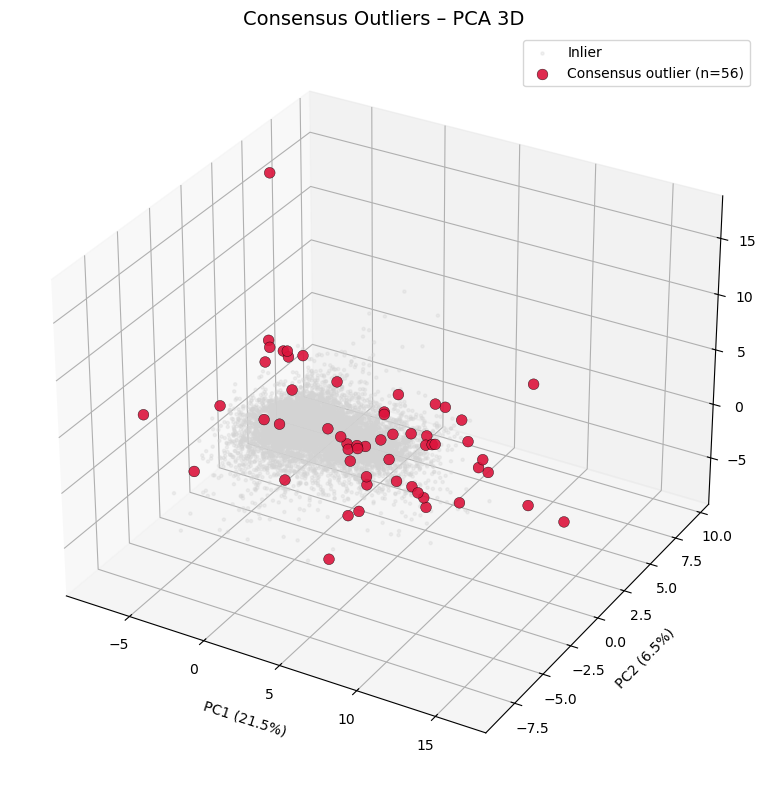

In [182]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[~consensus_mask, 0], X_3d[~consensus_mask, 1], X_3d[~consensus_mask, 2],
           c='lightgrey', s=5, alpha=0.3, label='Inlier')
ax.scatter(X_3d[consensus_mask,  0], X_3d[consensus_mask,  1], X_3d[consensus_mask,  2],
           c='crimson', s=60, alpha=0.9, edgecolors='k', linewidths=0.3,
           label=f'Consensus outlier (n={n_consensus})', zorder=4)

var = pca3.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)', labelpad=8)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)', labelpad=8)
ax.set_zlabel(f'PC3 ({var[2]*100:.1f}%)', labelpad=8)
ax.set_title('Consensus Outliers – PCA 3D', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


---
## 4. Outlier Characterisation

Before deciding how to handle outliers, we inspect *which features drive their anomaly scores*
by comparing the mean values of consensus outliers vs. the rest of the dataset.


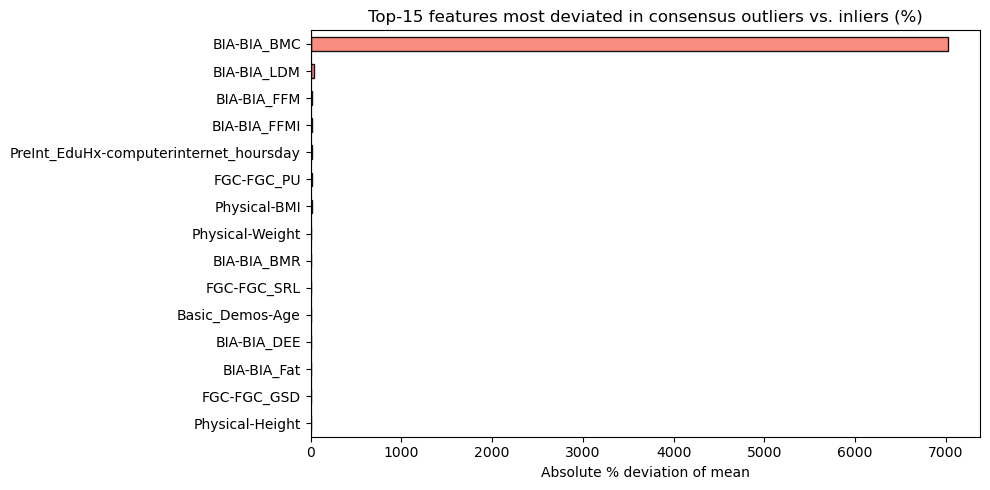

In [184]:
# Compare mean feature values: outliers vs inliers (in original, unscaled space)
out_idx = outlier_df[outlier_df['consensus'] == 1].index
in_idx  = outlier_df[outlier_df['consensus'] == 0].index

means_out = X_raw.loc[out_idx].mean()
means_in  = X_raw.loc[in_idx].mean()
diff = ((means_out - means_in) / (means_in.abs() + 1e-9)) * 100  # % deviation

diff_sorted = diff.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
diff_sorted[::-1].plot(kind='barh', ax=ax, color='salmon', edgecolor='k', alpha=0.9)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Top-15 features most deviated in consensus outliers vs. inliers (%)', fontsize=12)
ax.set_xlabel('Absolute % deviation of mean')
plt.tight_layout(); plt.show()


---
## Summary

| Method | Family | # Outliers flagged |
|--------|--------|--------------------|
| LOF    | Density-based | *filled at runtime* |
| ABOD   | Angle-based   | *filled at runtime* |
| Isolation Forest | Ensemble | *filled at runtime* |

**Observations:**
- LOF captures *local* density anomalies and tends to flag points that are isolated in dense neighborhoods.
- ABOD is sensitive to high-dimensional angle variance; it typically agrees with LOF on extreme outliers but diverges on borderline cases.
- Isolation Forest identifies points requiring fewer splits to isolate, making it robust in high dimensions and insensitive to feature scaling beyond what was already applied.
- The Jaccard overlap between pairs of methods shows moderate agreement, confirming that each method captures complementary aspects of anomaly.
- Consensus outliers (flagged by ≥2/3 methods) constitute approximately **1%** of the dataset and are concentrated in a specific region of the PCA projection, confirming they share structural characteristics.

**Next step (Module 1 – Imbalanced Learning):** consensus outliers will either be removed or have their anomalous feature values treated as missing and re-imputed.


In [186]:
df_clean = df[~consensus_mask].reset_index(drop=True)
print(f"Campioni prima: {len(df)}")
print(f"Campioni rimossi: {n_consensus}")
print(f"Campioni dopo: {len(df_clean)}")

Campioni prima: 8460
Campioni rimossi: 56
Campioni dopo: 8404


In [188]:
df_clean.to_csv("df_postoutliers.csv", index=False)